# COPD Detection from Chest X-Rays
**Goal:** Train a model to tell apart 3 things from a chest X-ray:
- **Emphysema** — a type of COPD (lung disease)
- **Normal** — healthy lungs
- **Other** — everything else (Covid, Pneumonia, TB)

**Our plan:**
1. Load the data
2. Check the data (integrity)
3. Look at the data (EDA)
4. Prepare the data (preprocessing)
5. Train a model

---
## Setup
First, install and import what we need.

In [3]:
%pip install pandas numpy matplotlib pillow scikit-learn torch torchvision -q

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available(
) else "No GPU")


True
NVIDIA GeForce RTX 5060 Laptop GPU


In [5]:
import zipfile
import io
import hashlib

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

print("Ready")

Ready


---
## Step 1 — Load the Data

Our images are inside a zip file.
The zip has this structure:
```
archive.zip
└── chest-xray/
    ├── train/
    │   ├── Emphysema/   ← 2050 images
    │   ├── Normal/      ← 2671 images
    │   ├── Covid-19/
    │   ├── Pneumonia-Bacterial/
    │   ├── Pneumonia-Viral/
    │   └── Tuberculosis/
    ├── val/
    └── test/
```
We will group Covid-19, Pneumonia, and Tuberculosis all into one class called **Other**.

First, let's just open the zip and peek inside.

In [6]:
\
ZIP = r"c:\Users\xia7m\Desktop\Ai engnniering project\archive (6).zip"

with zipfile.ZipFile(ZIP) as z:
    all_files = z.namelist()

print("Total entries in zip:", len(all_files))
print("First 5 entries:")
for f in all_files[:5]:
    print(" ", f)

Total entries in zip: 18036
First 5 entries:
  chest-xray/test/Covid-19/COVID-1.jpg
  chest-xray/test/Covid-19/COVID-1028.jpg
  chest-xray/test/Covid-19/COVID-1036.jpg
  chest-xray/test/Covid-19/COVID-1039.jpg
  chest-xray/test/Covid-19/COVID-1050.jpg


Now let's build a simple list of every image with its label.
We go through every file in the zip, check which folder it's in,
and assign it a label.

In [7]:
# This tells us which folder maps to which label
LABEL_MAP = {
    "Emphysema"           : "Emphysema",
    "Normal"              : "Normal",
    "Covid-19"            : "Other",
    "Pneumonia-Bacterial" : "Other",
    "Pneumonia-Viral"     : "Other",
    "Tuberculosis"        : "Other",
}

# We'll store everything as a list of dicts
train_data = []
val_data   = []
test_data  = []

with zipfile.ZipFile(ZIP) as z:
    for filepath in z.namelist():

        # Each path looks like: chest-xray/train/Emphysema/img001.jpg
        parts = filepath.split("/")
        if len(parts) != 4:
            continue

        _, split, folder, filename = parts

        # Skip folders, only keep image files
        if not filename.lower().endswith(".jpg"):
            continue

        # Skip unknown folders
        if folder not in LABEL_MAP:
            continue

        entry = {
            "path"  : filepath,
            "label" : LABEL_MAP[folder],
        }

        if split == "train": train_data.append(entry)
        if split == "val"  : val_data.append(entry)
        if split == "test" : test_data.append(entry)

print("Train images:", len(train_data))
print("Val images  :", len(val_data))
print("Test images :", len(test_data))

Train images: 11951
Val images  : 1450
Test images : 1450


Let's count how many images we have per class in the training set.

In [8]:
from collections import Counter

train_counts = Counter(item["label"] for item in train_data)

print("Training set breakdown:")
for label, count in train_counts.items():
    print(f"  {label:<12}: {count} images")

Training set breakdown:
  Other       : 7230 images
  Emphysema   : 2050 images
  Normal      : 2671 images


---
## Step 2 — Check the Data (Integrity)

Before we do any analysis or training, we want to make sure our data is clean.
We'll check for 3 things:
- **Broken images** — files that can't be opened
- **Blank images** — images that are all black or all white (failed scans)
- **Duplicates** — the same image appearing more than once

### 2.1 — Broken Images
We try to open every image. If it fails, we record it.
This might take a minute.

In [9]:
broken = []

with zipfile.ZipFile(ZIP) as z:
    for entry in train_data:
        try:
            with z.open(entry["path"]) as f:
                img = Image.open(f)
                img.verify()   # checks the file without fully loading it
        except Exception as e:
            broken.append(entry["path"])

print("Broken images found:", len(broken))
for b in broken:
    print(" ", b)

Broken images found: 0


### 2.2 — Blank Images
A blank image has a very low (all black) or very high (all white) average brightness.
We resize to 64×64 to make it fast, then check the average pixel value.

In [10]:
blank = []

with zipfile.ZipFile(ZIP) as z:
    for entry in train_data:
        with z.open(entry["path"]) as f:
            img = Image.open(f).convert("L").resize((64, 64))
            pixels = list(img.getdata())
            avg = sum(pixels) / len(pixels)   # 0 = black, 255 = white

        if avg < 10 or avg > 245:
            blank.append({"path": entry["path"], "label": entry["label"], "avg_brightness": round(avg, 1)})

print("Blank or near-white images found:", len(blank))
for b in blank:
    print(f"  {b['label']:<12}  brightness={b['avg_brightness']}  {b['path']}")

C:\Users\xia7m\AppData\Local\Temp\ipykernel_31668\1206015757.py:7: DeprecationWarning: Image.Image.getdata is deprecated and will be removed in Pillow 14 (2027-10-15). Use get_flattened_data instead.
  pixels = list(img.getdata())


Blank or near-white images found: 0


### 2.3 — Duplicate Images
We compute an MD5 hash of each image file.
If two files have the same hash, they are identical.

In [11]:
seen_hashes = {}
duplicates  = []

with zipfile.ZipFile(ZIP) as z:
    all_entries = train_data + val_data + test_data

    for entry in all_entries:
        with z.open(entry["path"]) as f:
            file_hash = hashlib.md5(f.read()).hexdigest()

        if file_hash in seen_hashes:
            duplicates.append({
                "copy_1" : seen_hashes[file_hash]["path"],
                "label_1": seen_hashes[file_hash]["label"],
                "copy_2" : entry["path"],
                "label_2": entry["label"],
            })
        else:
            seen_hashes[file_hash] = entry

print("Duplicate pairs found:", len(duplicates))

# Check if any duplicate has different labels (that would be a problem)
cross_class = [d for d in duplicates if d["label_1"] != d["label_2"]]
print("Cross-class duplicates (same image, different label):", len(cross_class))

if cross_class:
    print("WARNING — these need to be removed:")
    for d in cross_class:
        print(f"  {d['copy_1']} ({d['label_1']})  vs  {d['copy_2']} ({d['label_2']})")

Duplicate pairs found: 36
Cross-class duplicates (same image, different label): 0


### 2.4 — Clean Up
Now we remove the bad images from our lists.
We remove:
- All blank images
- All duplicate copies (keeping the first one)

In [12]:
# Paths to remove
paths_to_remove = set()

# Add blank image paths
for b in blank:
    paths_to_remove.add(b["path"])

# Add duplicate copy_2 paths (we keep copy_1)
for d in duplicates:
    paths_to_remove.add(d["copy_2"])

print("Images to remove:", len(paths_to_remove))

# Filter each split
train_data = [e for e in train_data if e["path"] not in paths_to_remove]
val_data   = [e for e in val_data   if e["path"] not in paths_to_remove]
test_data  = [e for e in test_data  if e["path"] not in paths_to_remove]

print("\nAfter cleaning:")
print("  Train:", len(train_data))
print("  Val  :", len(val_data))
print("  Test :", len(test_data))

Images to remove: 36

After cleaning:
  Train: 11931
  Val  : 1440
  Test : 1444


---
## Step 3 — Look at the Data (EDA)

Now that our data is clean, let's understand it visually.
We'll answer these questions:
- How many images per class?
- What do the images actually look like?
- Are all images the same size?
- How bright are the images?
- What does the "average" image look like per class?
- Where does Emphysema differ from Normal?

### 3.1 — How many images per class?

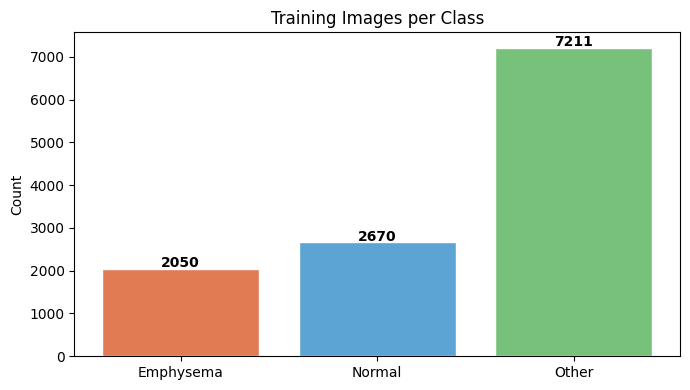

Notice: 'Other' has far more images than 'Emphysema'
This is called class imbalance — we'll handle it in training.


In [13]:
train_counts = Counter(e["label"] for e in train_data)
labels = ["Emphysema", "Normal", "Other"]
counts = [train_counts[l] for l in labels]
colors = ["#e07b54", "#5ba4d4", "#78c17a"]

plt.figure(figsize=(7, 4))
bars = plt.bar(labels, counts, color=colors, edgecolor="white")
for bar, val in zip(bars, counts):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
             str(val), ha="center", fontweight="bold")
plt.title("Training Images per Class")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

print("Notice: 'Other' has far more images than 'Emphysema'")
print("This is called class imbalance — we'll handle it in training.")

### 3.2 — What do the images look like?

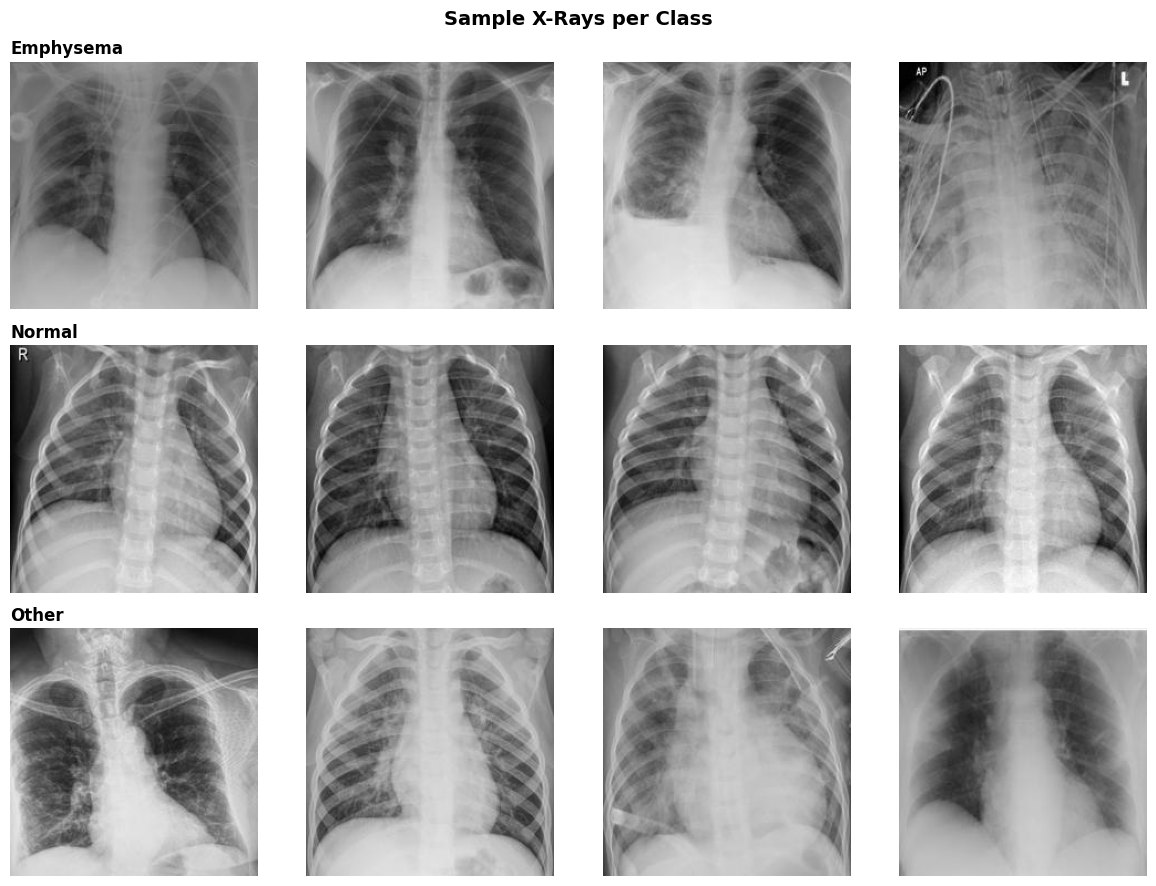

In [14]:
# Pick 4 random images from each class and show them
import random
random.seed(42)

fig, axes = plt.subplots(3, 4, figsize=(12, 9))

for row, label in enumerate(["Emphysema", "Normal", "Other"]):
    samples = [e for e in train_data if e["label"] == label]
    picked  = random.sample(samples, 4)

    for col, entry in enumerate(picked):
        with zipfile.ZipFile(ZIP) as z:
            with z.open(entry["path"]) as f:
                img = Image.open(f).convert("RGB").resize((224, 224))

        axes[row, col].imshow(img)
        axes[row, col].axis("off")
        if col == 0:
            axes[row, col].set_title(label, fontweight="bold", loc="left")

plt.suptitle("Sample X-Rays per Class", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

### 3.3 — Are all images the same size?

In [15]:
# Check 100 images from each class
widths  = []
heights = []
img_labels = []

with zipfile.ZipFile(ZIP) as z:
    for label in ["Emphysema", "Normal", "Other"]:
        samples = [e for e in train_data if e["label"] == label]
        for entry in random.sample(samples, 100):
            with z.open(entry["path"]) as f:
                img = Image.open(f)
                w, h = img.size
                widths.append(w)
                heights.append(h)
                img_labels.append(label)

print("Width  — min:", min(widths),  " max:", max(widths),  " avg:", round(sum(widths)/len(widths)))
print("Height — min:", min(heights), " max:", max(heights), " avg:", round(sum(heights)/len(heights)))
print()
print("Images are NOT all the same size.")
print("We will resize everything to 224x224 before training.")

Width  — min: 224  max: 224  avg: 224
Height — min: 224  max: 224  avg: 224

Images are NOT all the same size.
We will resize everything to 224x224 before training.


### 3.4 — How bright are the images? Are the classes different?

C:\Users\xia7m\AppData\Local\Temp\ipykernel_31668\995805601.py:9: DeprecationWarning: Image.Image.getdata is deprecated and will be removed in Pillow 14 (2027-10-15). Use get_flattened_data instead.
  pixels = list(img.getdata())


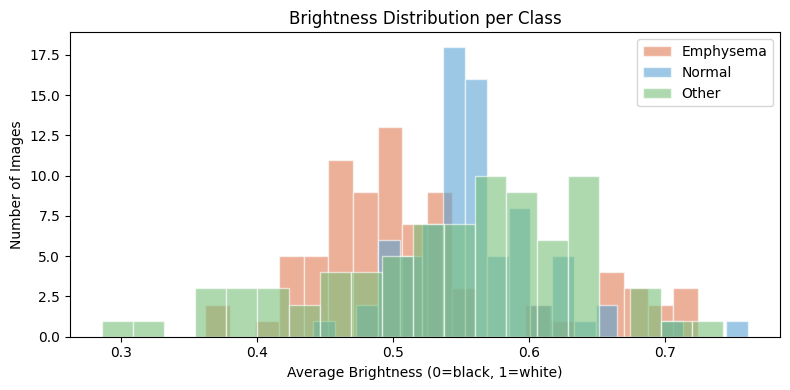

In [16]:
means_per_class = {"Emphysema": [], "Normal": [], "Other": []}

with zipfile.ZipFile(ZIP) as z:
    for label in ["Emphysema", "Normal", "Other"]:
        samples = [e for e in train_data if e["label"] == label]
        for entry in random.sample(samples, 80):
            with z.open(entry["path"]) as f:
                img   = Image.open(f).convert("L").resize((128, 128))
                pixels = list(img.getdata())
                avg    = sum(pixels) / len(pixels) / 255   # 0-1 scale
                means_per_class[label].append(avg)

plt.figure(figsize=(8, 4))
colors = {"Emphysema": "#e07b54", "Normal": "#5ba4d4", "Other": "#78c17a"}
for label, values in means_per_class.items():
    plt.hist(values, bins=20, alpha=0.6, label=label, color=colors[label], edgecolor="white")

plt.xlabel("Average Brightness (0=black, 1=white)")
plt.ylabel("Number of Images")
plt.title("Brightness Distribution per Class")
plt.legend()
plt.tight_layout()
plt.show()

### 3.5 — What does the average image look like per class?

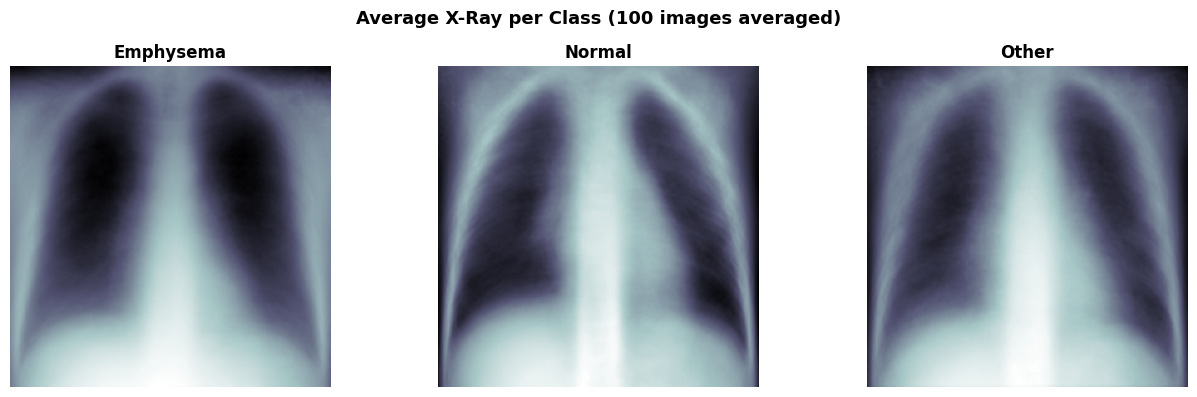

In [17]:
# Average 100 images together for each class
# This shows the 'typical' X-ray for each class

avg_images = {}

with zipfile.ZipFile(ZIP) as z:
    for label in ["Emphysema", "Normal", "Other"]:
        samples  = [e for e in train_data if e["label"] == label]
        stack    = []
        for entry in random.sample(samples, 100):
            with z.open(entry["path"]) as f:
                arr = np.array(Image.open(f).convert("L").resize((256, 256)), dtype=np.float32)
                stack.append(arr)
        avg_images[label] = np.mean(stack, axis=0)

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, label in zip(axes, ["Emphysema", "Normal", "Other"]):
    ax.imshow(avg_images[label], cmap="bone")
    ax.set_title(label, fontweight="bold")
    ax.axis("off")

plt.suptitle("Average X-Ray per Class (100 images averaged)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

### 3.6 — Where does Emphysema look different from Normal?

We subtract the two average images.
- **Red** = Emphysema is brighter there
- **Blue** = Normal is brighter there

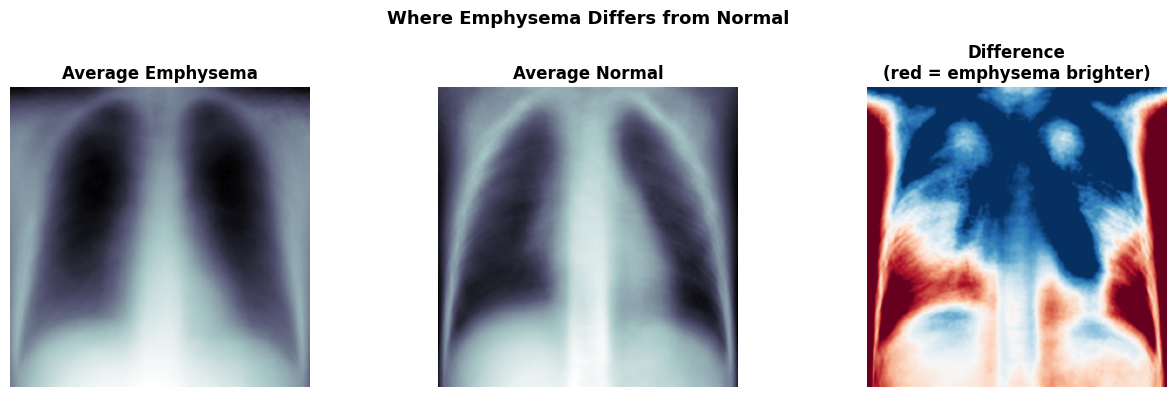

In [18]:
diff = avg_images["Emphysema"] - avg_images["Normal"]

fig, axes = plt.subplots(1, 3, figsize=(13, 4))

axes[0].imshow(avg_images["Emphysema"], cmap="bone")
axes[0].set_title("Average Emphysema", fontweight="bold")
axes[0].axis("off")

axes[1].imshow(avg_images["Normal"], cmap="bone")
axes[1].set_title("Average Normal", fontweight="bold")
axes[1].axis("off")

axes[2].imshow(diff, cmap="RdBu_r", vmin=-30, vmax=30)
axes[2].set_title("Difference\n(red = emphysema brighter)", fontweight="bold")
axes[2].axis("off")

plt.suptitle("Where Emphysema Differs from Normal", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

---
## Step 4 — Prepare the Data (Preprocessing)

Raw images can't go straight into a model. We need to:

1. **Resize** — all images to the same size (224×224)
2. **Convert to tensor** — from a PIL image to numbers PyTorch can use
3. **Normalize** — shift pixel values to a range the pretrained model expects
4. **Augment** — randomly flip/rotate training images so the model sees more variety

**We do NOT augment validation or test images** — we want those to be the real thing.

### 4.1 — Define the transforms

In [19]:
import torchvision.transforms as T

# For training — includes random changes to help the model generalize
train_transform = T.Compose([
    T.Resize((224, 224)),
    T.RandomHorizontalFlip(),         # randomly mirror the image
    T.RandomRotation(10),             # tilt up to 10 degrees
    T.ColorJitter(brightness=0.2, contrast=0.2),  # vary brightness slightly
    T.ToTensor(),                     # convert to PyTorch tensor
    T.Normalize([0.485, 0.456, 0.406],            # standard ImageNet values
                [0.229, 0.224, 0.225]),
])

# For validation and testing — no random changes, just resize and normalize
eval_transform = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize([0.485, 0.456, 0.406],
                [0.229, 0.224, 0.225]),
])

print("Transforms defined.")

Transforms defined.


### 4.2 — Preview the augmentation

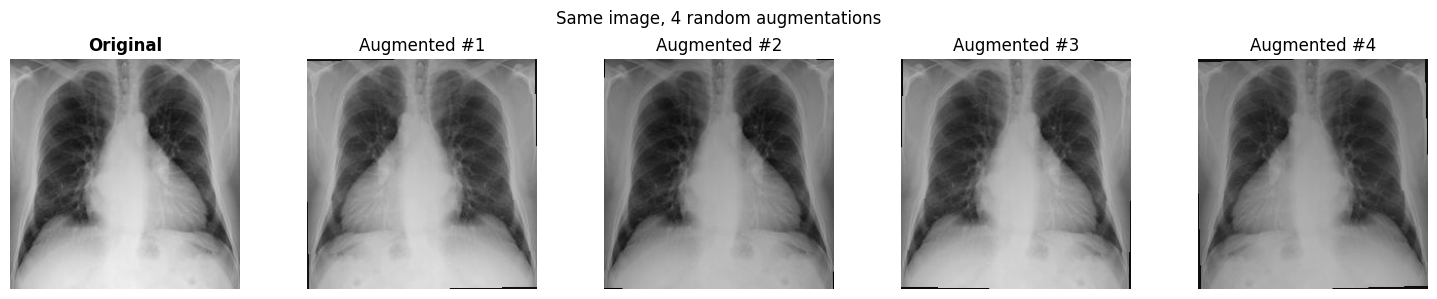

In [20]:
# Let's see what augmentation does to one image
emphysema_samples = [e for e in train_data if e["label"] == "Emphysema"]
sample_entry = emphysema_samples[0]

with zipfile.ZipFile(ZIP) as z:
    with z.open(sample_entry["path"]) as f:
        original = Image.open(f).convert("RGB")
        original.load()

# The augmentation without normalize so we can see the image
aug_preview = T.Compose([
    T.Resize((224, 224)),
    T.RandomHorizontalFlip(),
    T.RandomRotation(10),
    T.ColorJitter(brightness=0.2, contrast=0.2),
])

fig, axes = plt.subplots(1, 5, figsize=(15, 3))
axes[0].imshow(original.resize((224, 224)))
axes[0].set_title("Original", fontweight="bold")
axes[0].axis("off")

for i in range(1, 5):
    axes[i].imshow(aug_preview(original))
    axes[i].set_title(f"Augmented #{i}")
    axes[i].axis("off")

plt.suptitle("Same image, 4 random augmentations", fontsize=12)
plt.tight_layout()
plt.show()

### 4.3 — Build the Dataset class

In [21]:
import torch
from torch.utils.data import Dataset, DataLoader

LABEL_TO_NUM = {"Emphysema": 0, "Normal": 1, "Other": 2}

class XRayDataset(Dataset):

    def __init__(self, data, zip_path, transform):
        self.data      = data
        self.zip_path  = zip_path
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, i):
        entry = self.data[i]

        # Load image from zip
        with zipfile.ZipFile(self.zip_path) as z:
            with z.open(entry["path"]) as f:
                img = Image.open(f).convert("RGB")
                img.load()

        img   = self.transform(img)
        label = torch.tensor(LABEL_TO_NUM[entry["label"]])
        return img, label

print("Dataset class defined.")

Dataset class defined.


### 4.4 — Create the DataLoaders

In [22]:
# DataLoaders feed batches of images to the model during training

train_dataset = XRayDataset(train_data, ZIP, train_transform)
val_dataset   = XRayDataset(val_data,   ZIP, eval_transform)
test_dataset  = XRayDataset(test_data,  ZIP, eval_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False)

# Quick test — load one batch
images, labels = next(iter(train_loader))
print("Batch of images shape:", images.shape)   # should be [32, 3, 224, 224]
print("Batch of labels:", labels[:8].tolist())   # 0=Emphysema, 1=Normal, 2=Other

Batch of images shape: torch.Size([32, 3, 224, 224])
Batch of labels: [1, 2, 2, 2, 2, 2, 2, 2]


### 4.5 — Handle class imbalance

In [23]:
# Emphysema has fewer images than Other
# We tell the loss function to care more about getting Emphysema right

from sklearn.utils.class_weight import compute_class_weight

all_labels = [LABEL_TO_NUM[e["label"]] for e in train_data]

weights = compute_class_weight(
    class_weight = "balanced",
    classes      = np.array([0, 1, 2]),
    y            = all_labels
)

class_weights = torch.tensor(weights, dtype=torch.float32)

print("Class weights:")
print(f"  Emphysema (0): {class_weights[0]:.3f}  ← highest, fewest images")
print(f"  Normal    (1): {class_weights[1]:.3f}")
print(f"  Other     (2): {class_weights[2]:.3f}  ← lowest, most images")
print()
print("We will pass these into the loss function during training.")

Class weights:
  Emphysema (0): 1.940  ← highest, fewest images
  Normal    (1): 1.490
  Other     (2): 0.552  ← lowest, most images

We will pass these into the loss function during training.


---
## What's Next — Step 5: Training

We are now ready to train a model.

**Everything we have so far:**
- Clean data (blank + duplicates removed)
- DataLoaders (train / val / test)
- Class weights (for imbalance)

**Next we will:**
1. Load a pretrained model (DenseNet-121)
2. Swap its last layer to output 3 classes instead of 1000
3. Train it on our data
4. Check how well it does on the test set

Say **"train"** when you're ready.

---
## Step 5 — Train the Model

We will use **DenseNet-121** — a model that was already trained on millions of images.
We just swap its last layer so it outputs 3 classes instead of 1000.
This is called **transfer learning** — reusing what the model already knows.

### 5.1 — Load DenseNet-121 and swap the last layer

In [24]:
import torch
import torch.nn as nn
from torchvision import models

# Load DenseNet-121 pretrained on ImageNet
model = models.densenet121(weights="IMAGENET1K_V1")

# The last layer currently outputs 1000 classes
# We replace it to output 3 (Emphysema, Normal, Other)
num_features = model.classifier.in_features
model.classifier = nn.Linear(num_features, 3)

print("Model ready.")
print(f"Input features : {num_features}")
print(f"Output classes : 3  (0=Emphysema, 1=Normal, 2=Other)")

Model ready.
Input features : 1024
Output classes : 3  (0=Emphysema, 1=Normal, 2=Other)


### 5.2 — Set up the loss function and optimizer

- **Loss function** — measures how wrong the model is. We use class weights so it cares more about Emphysema (the smallest class).
- **Optimizer** — adjusts the model weights to reduce the loss. We use Adam.

In [25]:
# Move model to GPU if available, otherwise CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model  = model.to(device)

print("Using device:", device)

# Loss function — weighted so Emphysema errors are penalized more
criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))

# Optimizer — Adam with a small learning rate
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)

print("Loss function and optimizer ready.")

Using device: cuda
Loss function and optimizer ready.


### 5.3 — The training loop

This is the core of training. For each batch of images:
1. Feed the images into the model
2. Compare the model's predictions to the real labels (loss)
3. Calculate how to adjust the weights to do better (backprop)
4. Update the weights (optimizer step)

We do this for every batch, for several epochs.

In [26]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()   # tell the model it's in training mode
    total_loss = 0
    correct    = 0
    total      = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        # Step 1: forward pass — get predictions
        outputs = model(images)

        # Step 2: calculate loss
        loss = criterion(outputs, labels)

        # Step 3: backward pass — calculate gradients
        optimizer.zero_grad()
        loss.backward()

        # Step 4: update weights
        optimizer.step()

        # Track accuracy
        predictions = outputs.argmax(dim=1)
        correct    += (predictions == labels).sum().item()
        total      += labels.size(0)
        total_loss += loss.item()

    avg_loss = total_loss / len(loader)
    accuracy = correct / total * 100
    return avg_loss, accuracy

print("train_one_epoch() defined.")

train_one_epoch() defined.


### 5.4 — Validation loop (run after each epoch to check progress)

In [27]:
def evaluate(model, loader, criterion, device):
    model.eval()   # tell the model it's in evaluation mode (no dropout, etc.)
    total_loss = 0
    correct    = 0
    total      = 0

    with torch.no_grad():   # don't calculate gradients (faster, saves memory)
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs     = model(images)
            loss        = criterion(outputs, labels)
            predictions = outputs.argmax(dim=1)

            correct    += (predictions == labels).sum().item()
            total      += labels.size(0)
            total_loss += loss.item()

    avg_loss = total_loss / len(loader)
    accuracy = correct / total * 100
    return avg_loss, accuracy

print("evaluate() defined.")

evaluate() defined.


### 5.5 — Run training for 10 epochs

One **epoch** = the model has seen every training image once.
After each epoch we check the validation accuracy.
We save the model whenever it improves.

In [28]:
EPOCHS     = 10
best_val_acc = 0

history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

for epoch in range(1, EPOCHS + 1):

    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss,   val_acc   = evaluate(model, val_loader, criterion, device)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    # Save model if validation accuracy improved
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "best_model.pth")
        saved = " ← saved"
    else:
        saved = ""

    print(f"Epoch {epoch:02d}/{EPOCHS}  "
          f"train_loss={train_loss:.3f}  train_acc={train_acc:.1f}%  "
          f"val_loss={val_loss:.3f}  val_acc={val_acc:.1f}%{saved}")

print(f"\nBest validation accuracy: {best_val_acc:.1f}%")

Epoch 01/10  train_loss=0.243  train_acc=87.9%  val_loss=0.304  val_acc=88.5% ← saved
Epoch 02/10  train_loss=0.121  train_acc=94.5%  val_loss=0.196  val_acc=93.3% ← saved
Epoch 03/10  train_loss=0.105  train_acc=95.2%  val_loss=0.096  val_acc=96.5% ← saved
Epoch 04/10  train_loss=0.080  train_acc=96.5%  val_loss=0.088  val_acc=96.8% ← saved
Epoch 05/10  train_loss=0.069  train_acc=97.0%  val_loss=0.127  val_acc=95.3%
Epoch 06/10  train_loss=0.065  train_acc=97.1%  val_loss=0.109  val_acc=96.5%
Epoch 07/10  train_loss=0.054  train_acc=97.7%  val_loss=0.097  val_acc=96.7%
Epoch 08/10  train_loss=0.053  train_acc=97.6%  val_loss=0.086  val_acc=97.2% ← saved
Epoch 09/10  train_loss=0.039  train_acc=98.4%  val_loss=0.062  val_acc=97.8% ← saved
Epoch 10/10  train_loss=0.042  train_acc=98.0%  val_loss=0.118  val_acc=96.5%

Best validation accuracy: 97.8%


### 5.6 — Plot training history

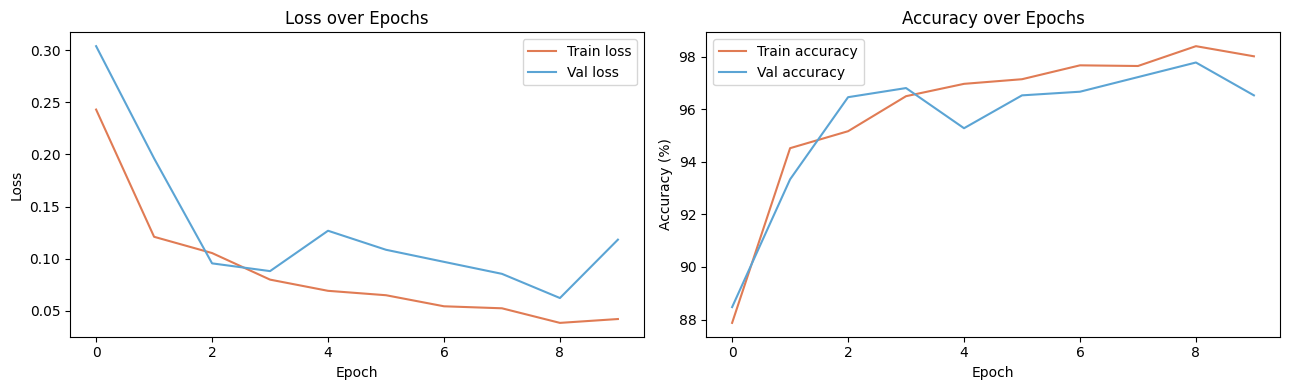

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(history["train_loss"], label="Train loss", color="#e07b54")
axes[0].plot(history["val_loss"],   label="Val loss",   color="#5ba4d4")
axes[0].set_title("Loss over Epochs")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()

axes[1].plot(history["train_acc"], label="Train accuracy", color="#e07b54")
axes[1].plot(history["val_acc"],   label="Val accuracy",   color="#5ba4d4")
axes[1].set_title("Accuracy over Epochs")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy (%)")
axes[1].legend()

plt.tight_layout()
plt.show()

### 5.7 — Evaluate on the test set

We load the best saved model and run it on the test set.
The test set was never used during training — so this is a fair measure.

In [30]:
# Load the best model weights
model.load_state_dict(torch.load("best_model.pth", map_location=device))

test_loss, test_acc = evaluate(model, test_loader, criterion, device)

print(f"Test loss     : {test_loss:.3f}")
print(f"Test accuracy : {test_acc:.1f}%")

Test loss     : 0.078
Test accuracy : 97.6%


### 5.8 — Confusion matrix

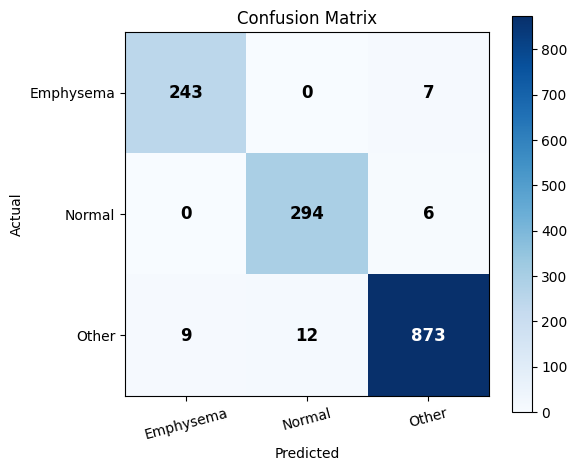

              precision    recall  f1-score   support

   Emphysema       0.96      0.97      0.97       250
      Normal       0.96      0.98      0.97       300
       Other       0.99      0.98      0.98       894

    accuracy                           0.98      1444
   macro avg       0.97      0.98      0.97      1444
weighted avg       0.98      0.98      0.98      1444



In [31]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

all_preds  = []
all_labels = []

model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        outputs     = model(images.to(device))
        predictions = outputs.argmax(dim=1).cpu().tolist()
        all_preds  += predictions
        all_labels += labels.tolist()

# Plot confusion matrix
cm     = confusion_matrix(all_labels, all_preds)
labels = ["Emphysema", "Normal", "Other"]

plt.figure(figsize=(6, 5))
plt.imshow(cm, cmap="Blues")
plt.colorbar()
plt.xticks([0, 1, 2], labels, rotation=15)
plt.yticks([0, 1, 2], labels)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

for i in range(3):
    for j in range(3):
        plt.text(j, i, cm[i, j], ha="center", va="center",
                 color="white" if cm[i, j] > cm.max()/2 else "black",
                 fontweight="bold", fontsize=12)

plt.tight_layout()
plt.show()

# Per-class report
print(classification_report(all_labels, all_preds, target_names=labels))